# Coding challenge - Andrea Álvarez 

## 1. Preprocessing 

In [10]:
import pandas as pd
import os
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
print(os.getcwd())
df = pd.read_csv('loan_dataset.csv',index_col=False,delimiter=";")   

/Users/andreaalvarezsanchez/Desktop/GitHub/coding-challenge-data-gov-fintech


Let's start by taking a look at the data, the number of variables, the observations, and the type of data we work with. 

In [12]:
print(df.head())
df.info()
print("\nDataset shape:", df.shape)

print("\nColumns:", df.columns.tolist())

   customer_id  age  ...  payment_to_income_ratio  loan_status
0        35467   63  ...                    0.234       repaid
1        23067   38  ...                    0.193       repaid
2         8591   48  ...                    0.214       repaid
3         9983   52  ...                    0.389       repaid
4        21525   55  ...                    0.500      default

[5 rows x 22 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  int64  
 1   age                      50000 non-null  int64  
 2   income                   50000 non-null  float64
 3   loan_amount              50000 non-null  float64
 4   loan_term_months         50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   employment_length_years  50000 non-null  float64
 7  

Some columns look irrelevant at first sights for the purpose of our analysis, so we proceed to drop them. 

In [13]:
# Drop irrelevant columns
columns_to_drop = ['customer_id', 'application_date']  #for now those are the ones I want to drop
df_clean = df.drop(columns=columns_to_drop)

print("\nShape after dropping columns:", df_clean.shape)


Shape after dropping columns: (50000, 20)


In [14]:
#Let's take a look at the categorical variables
df_clean['zip_code_prefix'] = df_clean['zip_code_prefix'].astype('category') #did not appear as categoric and the description says it should be treated as one
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print("The categorical columns are:", categorical_cols)

# Count unique values per categorical column
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts(normalize=True))  

The categorical columns are: ['education_level', 'zip_code_prefix', 'home_ownership', 'application_type', 'loan_purpose', 'loan_status']

--- education_level ---
education_level
bachelors      0.39754
high_school    0.30072
masters        0.20126
phd            0.10048
Name: proportion, dtype: float64

--- zip_code_prefix ---
zip_code_prefix
30    0.30068
20    0.24646
40    0.20134
10    0.14900
50    0.10252
Name: proportion, dtype: float64

--- home_ownership ---
home_ownership
mortgage    0.40480
rent        0.34892
own         0.24628
Name: proportion, dtype: float64

--- application_type ---
application_type
online       0.60480
in_person    0.29648
phone        0.09872
Name: proportion, dtype: float64

--- loan_purpose ---
loan_purpose
debt_consolidation    0.39742
car                   0.20214
business              0.15094
home_improvement      0.14912
other                 0.10038
Name: proportion, dtype: float64

--- loan_status ---
loan_status
repaid     0.62432
default    0

From the results of the percentage of data of each type, we can notice that the category 'phd' in the variable education has a percentage low but stil considerable (around 10%), so we will not delete it. The category 'phone' has a more pronunced low percentage (~10%), but still reasonable, so we will keep it for now.

Now, let's do a copy of the dataframe. Then, we first map our target variable and then we enconde the rest of the categorical variables that are in the dataset, setting as the baseline the categories that are more common. 

In [15]:
df_encoded = df_clean.copy()

df_encoded['loan_status'] = df_encoded['loan_status'].map({'repaid': 0, 'default': 1}) #If pd.get_dummies() on everything at once, you risk turning your target into dummy columns too

categorical_cols = ['education_level', 'home_ownership', 'application_type', 'loan_purpose', 'zip_code_prefix']

edu_order = CategoricalDtype(['bachelors', 'high_school', 'masters', 'phd'], ordered=True)
df_clean['education_level'] = df_clean['education_level'].astype(edu_order)

zip_order = CategoricalDtype(['30', '20', '40', '10', '50'], ordered=True)
df_clean['zip_code_prefix'] = df_clean['zip_code_prefix'].astype(zip_order)

home_order = CategoricalDtype(['mortgage', 'rent', 'own'], ordered=True)
df_clean['home_ownership'] = df_clean['home_ownership'].astype(home_order)

app_order = CategoricalDtype(['online', 'in_person', 'phone'], ordered=True)
df_clean['application_type'] = df_clean['application_type'].astype(app_order)

loan_purpose_order = CategoricalDtype(['debt_consolidation', 'car', 'business', 'home_improvement', 'other'], ordered=True)
df_clean['loan_purpose'] = df_clean['loan_purpose'].astype(loan_purpose_order)


df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", df_encoded.shape)
print("\nColumns after encoding:", df_encoded.columns.tolist())




Shape after encoding: (50000, 30)

Columns after encoding: ['age', 'income', 'loan_amount', 'loan_term_months', 'credit_score', 'employment_length_years', 'debt_to_income_ratio', 'savings_amount', 'previous_defaults', 'has_cosigner', 'existing_customer', 'loan_to_income_ratio', 'monthly_payment', 'payment_to_income_ratio', 'loan_status', 'education_level_high_school', 'education_level_masters', 'education_level_phd', 'home_ownership_rent', 'home_ownership_own', 'application_type_in_person', 'application_type_phone', 'loan_purpose_car', 'loan_purpose_business', 'loan_purpose_home_improvement', 'loan_purpose_other', 'zip_code_prefix_20', 'zip_code_prefix_40', 'zip_code_prefix_10', 'zip_code_prefix_50']


### Summary Statistics

In [16]:
numerical_cols_clean = [
    'age', 'income', 'loan_amount', 'loan_term_months', 'credit_score',
    'employment_length_years', 'debt_to_income_ratio', 'savings_amount',
    'previous_defaults', 'loan_to_income_ratio', 'monthly_payment', 'payment_to_income_ratio'
]
df_encoded[numerical_cols_clean].describe(),round(2)

(                age         income  ...  monthly_payment  payment_to_income_ratio
 count  50000.000000   50000.000000  ...     50000.000000             50000.000000
 mean      44.002820   60133.980000  ...       752.350952                 0.173547
 std       15.269871   29597.663249  ...       619.605202                 0.135225
 min       18.000000   20000.000000  ...        18.870000                 0.003000
 25%       31.000000   38000.000000  ...       361.560000                 0.072000
 50%       44.000000   55000.000000  ...       583.490000                 0.130000
 75%       57.000000   76000.000000  ...       934.990000                 0.236000
 max       70.000000  300000.000000  ...      7644.750000                 0.500000
 
 [8 rows x 12 columns],
 2)

We reviewed the summary statistics for all numerical variables to understand the basic distribution of the data. Most variables appear to be within reasonable and expected ranges. For example, income ranges from €20,000 to €300,000, with a median around €55,000, while loan amounts vary between €1,000 and €121,700, with a median of approximately €18,700. The credit score distribution is centered around 708, and savings amounts show a wide range, from €0 up to about €183,000. Ratios like loan-to-income and payment-to-income are skewed towards lower values but reach maximums of 2.0 and 0.5, respectively. Overall, no unusual values or data entry errors were detected, and the statistics align well with typical patterns found in financial lending data.

We also examined the distribution of categorical variables in another section, which confirmed good variety across categories and provided a solid foundation for modeling. For example, regarding the education level, the majority of applicants have a bachelor’s degree (about 40%) or a high school diploma (30%), with smaller groups holding masters (20%) and PhD degrees (10%) or, the target variable, loan status, shows that around 62% of loans were repaid, while 38% defaulted. 

### Outliers detection

Afterwards, we focus on detecting potential outliers in the numerical variables of our dataset. Outliers can significantly affect certain machine learning models, especially linear ones like logistic regression. To systematically identify outliers, we apply the Interquartile Range (IQR) method, which flags observations that fall well outside the typical range of values (1.5 times the IQR below the first quartile or above the third quartile). We also visualize distributions using boxplots to better understand where do extreme values appear. This allows us to decide what to do with those outliers (removed, capped, or retained), depending on their frequency and potential impact on model performance.

This are the numerical columns: ['age', 'income', 'loan_amount', 'loan_term_months', 'credit_score', 'employment_length_years', 'debt_to_income_ratio', 'savings_amount', 'previous_defaults', 'has_cosigner', 'existing_customer', 'loan_to_income_ratio', 'monthly_payment', 'payment_to_income_ratio']


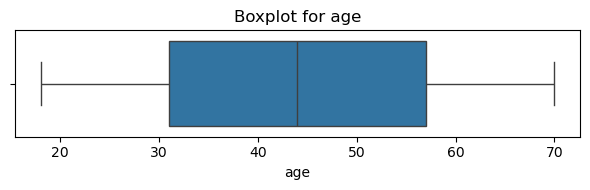

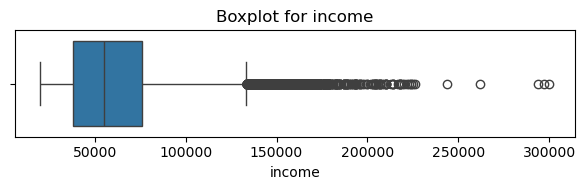

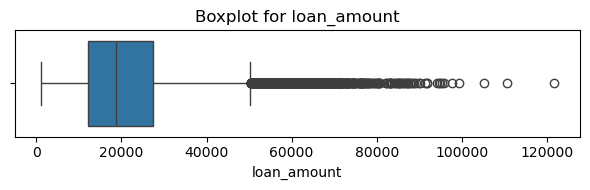

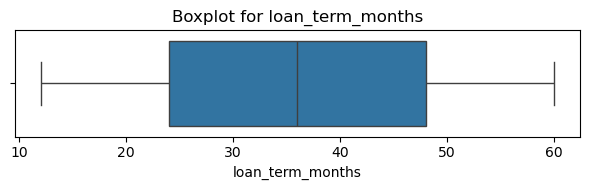

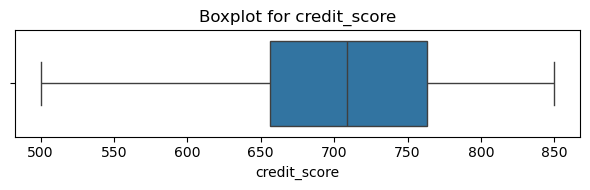

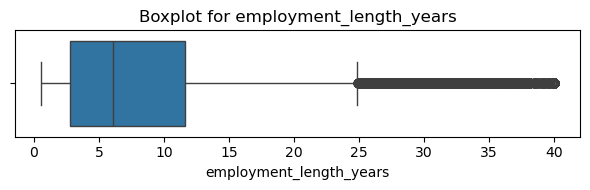

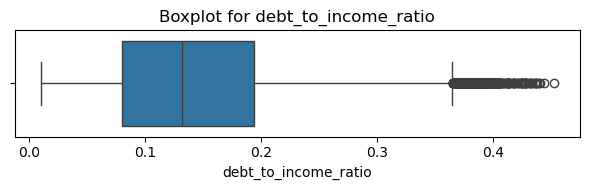

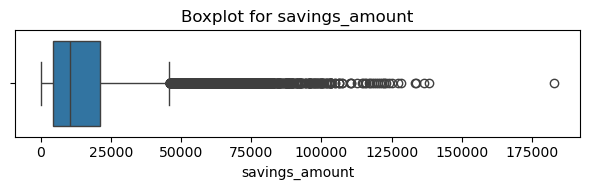

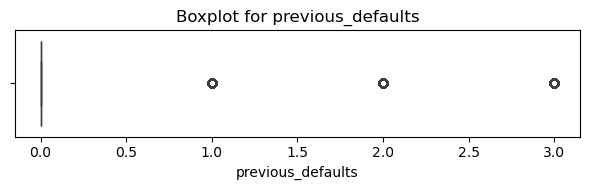

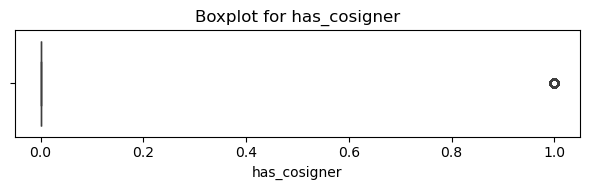

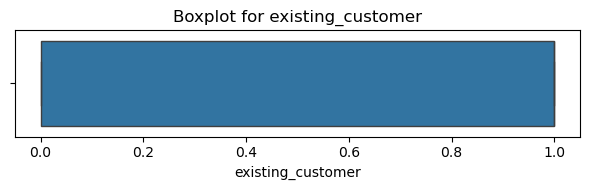

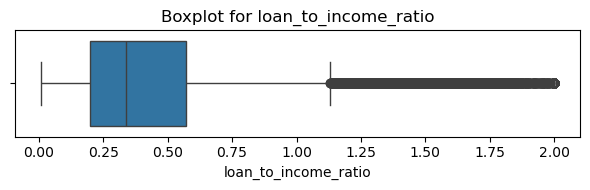

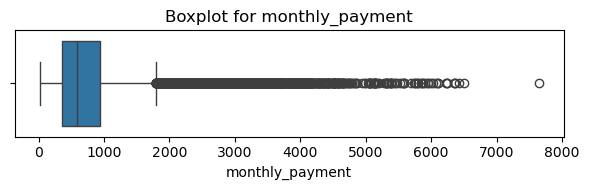

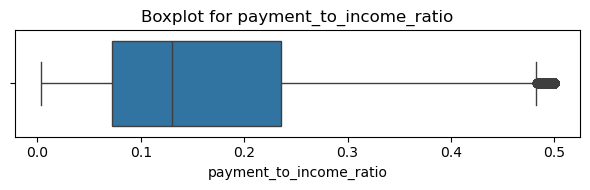

In [17]:
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("This are the numerical columns:", numerical_cols)

for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df_encoded[col])
    plt.title(f"Boxplot for {col}")
    plt.tight_layout()
    plt.show()

In [18]:
outlier_rows = pd.DataFrame(index=df_encoded.index)

for col in numerical_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_rows[col] = ~df_encoded[col].between(lower, upper)

outlier_rows['outlier_count'] = outlier_rows.sum(axis=1)

print(outlier_rows['outlier_count'].value_counts())
print("Number of rows with at least one outlier:", (outlier_rows['outlier_count'] > 0).sum())


outlier_count
0    27815
1    15443
2     4777
3     1355
4      479
5      113
6       18
Name: count, dtype: int64
Number of rows with at least one outlier: 22185


When we look at the boxplots, we can see that some variables—like income, loan amount, savings amount, and monthly payment—have a few really high values. This is pretty normal in financial data because some people have much bigger loans or higher incomes than others.
For other variables, like credit score, age, and loan term, everything looks clean and as expected.
Using the IQR method, we also found that about 44% of the rows in the dataset have at least one variable flagged as an outlier. In most cases, these outliers are due to just one or two variables, and only a very small number of rows (around 0.03% of the dataset) have extreme values across multiple variables.
At this point, I’m not removing any data because these high values seem realistic (for example, some clients are just richer or borrow more). But later, if we see that these extreme values are causing problems for the model—especially for logistic regression—we can cap them (for example, set a maximum value at the 99th percentile) to make sure they don’t have too much influence.

### Correlations 

                              age  ...  payment_to_income_ratio
age                      1.000000  ...                -0.004630
income                  -0.000418  ...                -0.486075
loan_amount             -0.001290  ...                 0.596812
loan_term_months         0.001456  ...                -0.444463
credit_score             0.006517  ...                -0.008652
employment_length_years  0.002524  ...                -0.003123
debt_to_income_ratio    -0.003578  ...                -0.005768
savings_amount           0.007751  ...                -0.004735
previous_defaults       -0.000988  ...                -0.003557
loan_to_income_ratio    -0.004904  ...                 0.819752
monthly_payment         -0.003644  ...                 0.743229
payment_to_income_ratio -0.004630  ...                 1.000000

[12 rows x 12 columns]


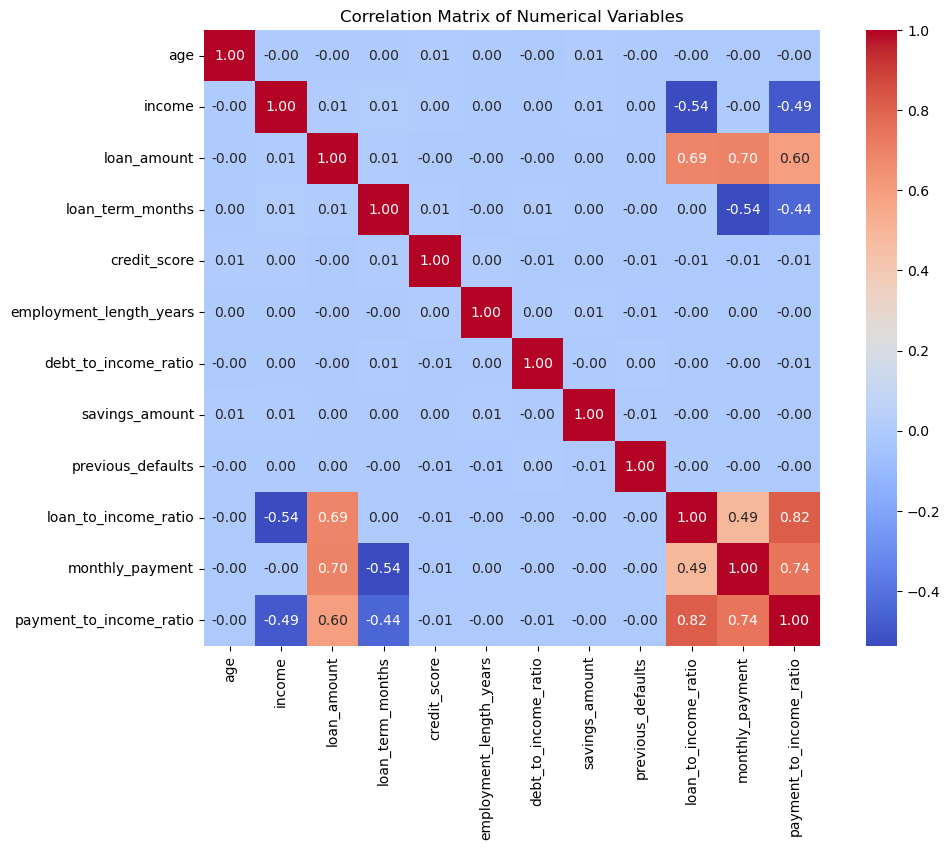

In [19]:
corr_matrix = df_encoded[numerical_cols_clean].corr()

print(corr_matrix)


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()


The correlation analysis shows that most variables are not strongly correlated, except for a few cases. In particular, loan_to_income_ratio, payment_to_income_ratio, and monthly_payment are highly correlated (above 0.8), which is logical because these variables are all related to the size of the loan relative to income. 

For the modeling part, especially with logistic regression, it may be wise to avoid including all three together to reduce multicollinearity risk. Other variables like age, credit_score, and loan_term_months show minimal correlation with others, which supports their independent value in prediction.

### Standardization 

We scal all the continuous numeric variables, which is important for logistic regression because it helps the model work better and keeps things balanced. For tree-based models like Random Forest, scaling isn’t needed, but we kept the scaled version so we can easily test different models later.

In [20]:
scaler = StandardScaler()

df_encoded_scaled = df_encoded.copy()
df_encoded_scaled[numerical_cols_clean] = scaler.fit_transform(df_encoded_scaled[numerical_cols_clean])

df_encoded_scaled[numerical_cols_clean].describe().round(2)


,age,income,loan_amount,loan_term_months,credit_score,employment_length_years,debt_to_income_ratio,savings_amount,previous_defaults,loan_to_income_ratio,monthly_payment,payment_to_income_ratio
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.70,-1.36,-1.65,-1.83,-2.71,-1.03,-1.66,-1.01,-0.38,-1.23,-1.18,-1.26
25%,-0.85,-0.75,-0.74,-0.91,-0.68,-0.73,-0.79,-0.71,-0.38,-0.69,-0.63,-0.75
50%,-0.00,-0.17,-0.19,-0.00,0.01,-0.30,-0.14,-0.31,-0.38,-0.29,-0.27,-0.32
75%,0.85,0.54,0.52,0.91,0.71,0.41,0.64,0.40,-0.38,0.36,0.29,0.46
max,1.70,8.10,8.28,1.83,1.84,4.10,3.87,11.22,5.09,4.38,11.12,2.41


### Skewness

We checked the skewness and plotted histograms for all numerical variables to see how their values are distributed. This helps us understand if variables are symmetric or skewed (for example, income tends to have a right-skewed distribution) and  decide later if we need to apply transformations like log scaling to improve model performance.


age
Skewness: 0.01


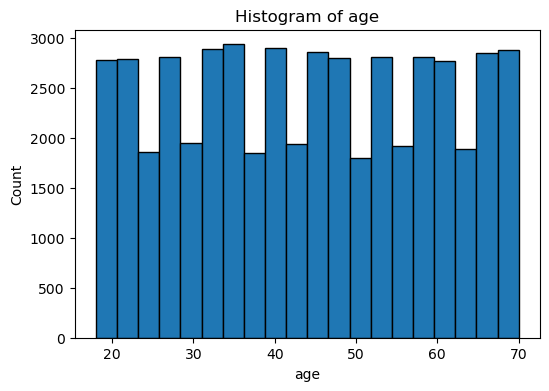


income
Skewness: 1.08


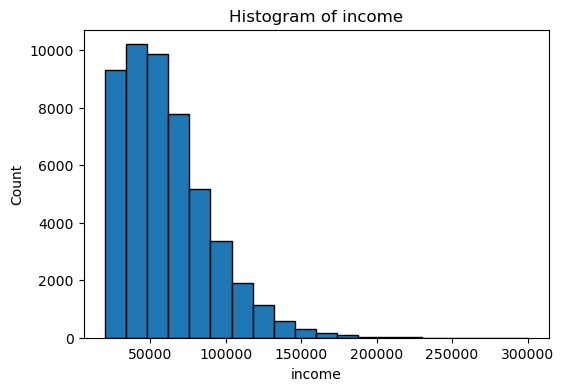


loan_amount
Skewness: 1.18


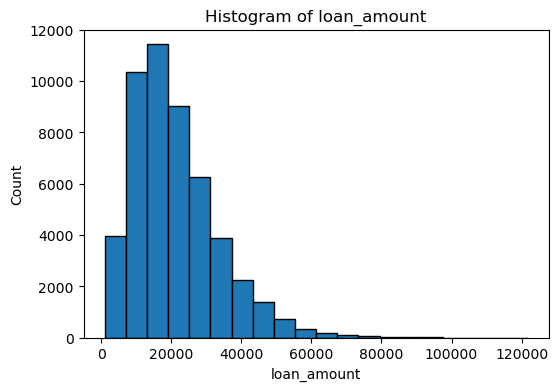


loan_term_months
Skewness: -0.0


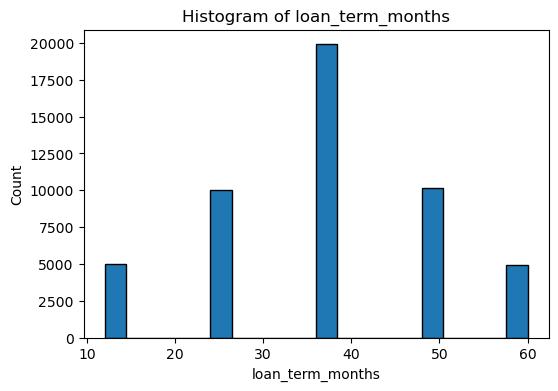


credit_score
Skewness: -0.15


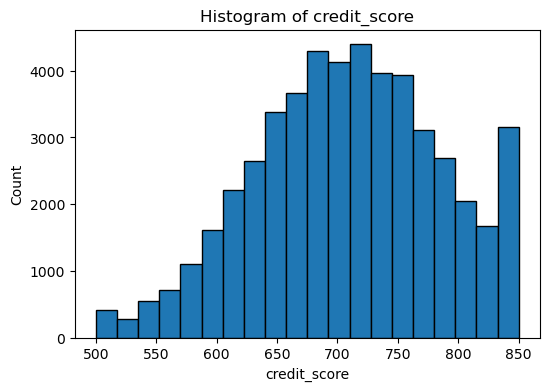


employment_length_years
Skewness: 1.64


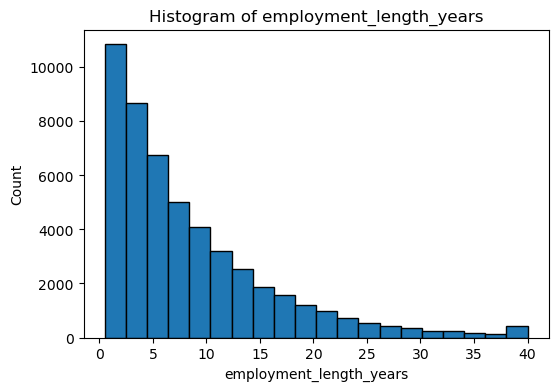


debt_to_income_ratio
Skewness: 0.6


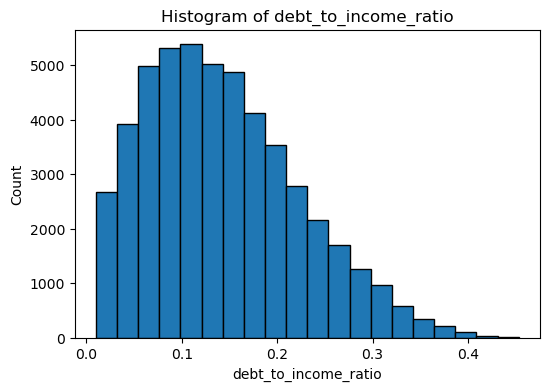


savings_amount
Skewness: 1.93


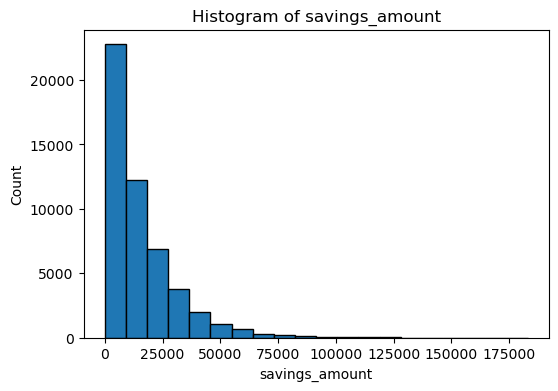


previous_defaults
Skewness: 2.91


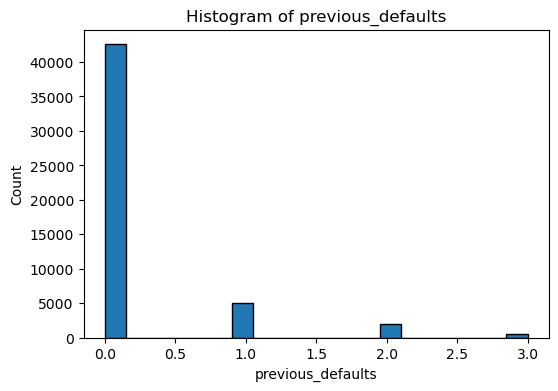


loan_to_income_ratio
Skewness: 1.81


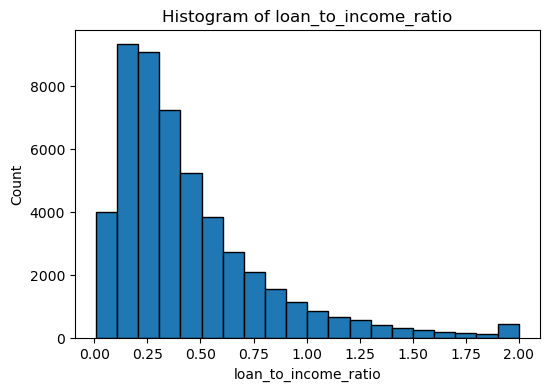


monthly_payment
Skewness: 2.61


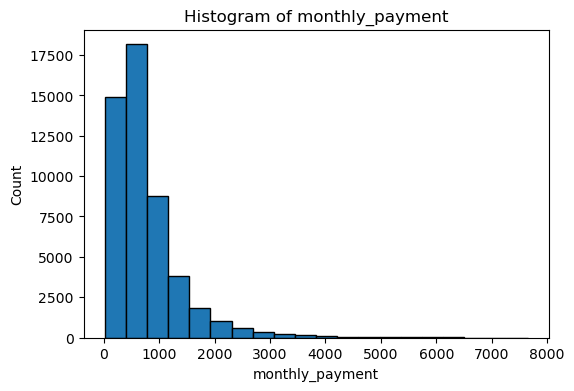


payment_to_income_ratio
Skewness: 1.13


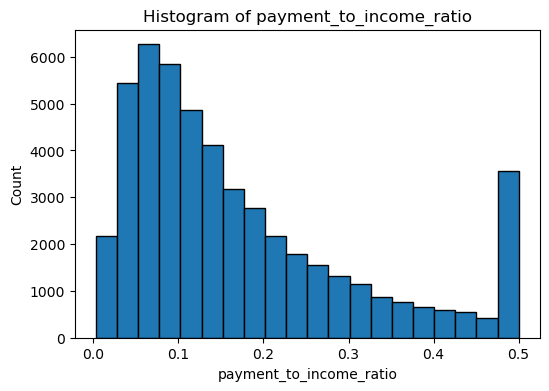

In [21]:
for feature in numerical_cols_clean:
    print(f"\n{feature}")
    print('Skewness:', round(df_encoded[feature].skew(), 2))

    plt.figure(figsize=(6, 4))
    plt.hist(df_encoded[feature], bins=20, edgecolor='k')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

Most numeric variables look fine, but a few (like income, loan amount, and savings) are very skewed because some people have much bigger loans or higher incomes. This is normal, but we might consider log-transforming these in the future if it helps the model work better. Other variables, like credit score and age, look clean and don’t need changes.

### Checking balance

We checked the distribution of the dependent variable (loan_status). The dataset has around 62% repaid loans and 38% defaulted loans. This shows a mild class imbalance but not extreme, just something to consider during modeling. To handle this, we could use options like class_weight='balanced' in logistic regression or rely on tree-based models, which handle imbalance more robustly. At this point, no additional resampling (like SMOTE) has been applied.

Class Counts:
 loan_status
repaid     31216
default    18784
Name: count, dtype: int64

Class Percentages:
 loan_status
repaid     0.62
default    0.38
Name: proportion, dtype: float64


/var/folders/xk/099rblcn2k99szyfbf_t878r0000gn/T/ipykernel_1419/1811553225.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df_clean, palette='pastel')


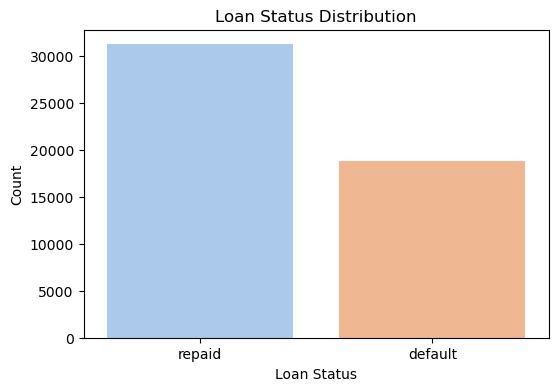

In [22]:
class_counts = df_clean['loan_status'].value_counts()
class_percentages = df_clean['loan_status'].value_counts(normalize=True).round(2)

print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", class_percentages)

plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df_clean, palette='pastel')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()


## 2. Modeling 

We want to separate the data into training and test sets ( 80%/20%).

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Define X and y
X = df_encoded_scaled.drop(columns='loan_status')
y = df_encoded_scaled['loan_status']

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (40000, 29)
Test shape: (10000, 29)
